# Car Market Trends Analysis Using CarDekho Data

## A Data Analysis Minor Project

### Submitted By
**C PUSHPALATHA**

**AICTE ID:** STU696132c929d891767977673

**College:** Justice Basheer Ahmed Sayeed College for Women

**GitHub:** cpushpalatha9

---

### Project Overview

This project analyzes used-car market data from CarDekho to understand the factors that influence the selling price of used cars.

The analysis focuses on present price, car age, kilometers driven, fuel type, seller type, transmission type, and ownership history.

The project uses Python-based data analysis, visualization, feature engineering, and machine learning techniques to identify important patterns and trends in the used-car market.


# Problem Statement

The used-car market contains many factors that can affect the selling price of a vehicle.

Factors such as the original present price, age of the car, kilometers driven, fuel type, seller type, transmission, and number of previous owners may influence the final selling price.

The objective of this project is to analyze CarDekho used-car data and identify the major factors affecting vehicle prices.


# Objectives

1. Analyze the CarDekho used-car dataset.
2. Understand the structure and characteristics of the data.
3. Clean and preprocess the dataset.
4. Analyze the relationship between present price and selling price.
5. Study the effect of car age on selling price.
6. Analyze the effect of kilometers driven.
7. Compare prices across different fuel types.
8. Compare dealer and individual sellers.
9. Analyze manual and automatic transmission vehicles.
10. Study the effect of vehicle ownership.
11. Identify the most and least expensive car models.
12. Perform correlation analysis.
13. Identify potential outliers.
14. Apply machine learning models to predict selling prices.
15. Generate useful business insights from the analysis.


In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# Upload the CarDekho CSV file in Google Colab

from google.colab import files
import io

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df_raw = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("File loaded successfully!")
print("File name:", file_name)
print("Dataset shape:", df_raw.shape)


Saving 1776311302-P3-Car Market Trends Analysis with Car Dekho Data (1).csv to 1776311302-P3-Car Market Trends Analysis with Car Dekho Data (1).csv
File loaded successfully!
File name: 1776311302-P3-Car Market Trends Analysis with Car Dekho Data (1).csv
Dataset shape: (301, 9)


In [3]:
# Display first 5 rows
df_raw.head()


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
# Dataset information
print("Dataset Shape:", df_raw.shape)
print("\nColumn Names:")
print(df_raw.columns.tolist())
print("\nDataset Information:")
df_raw.info()


Dataset Shape: (301, 9)

Column Names:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [5]:
# Statistical summary
df_raw.describe()


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [6]:
# Check missing values
missing_values = df_raw.isnull().sum()
print("Missing values in each column:")
print(missing_values)
print("\nTotal missing values:", missing_values.sum())


Missing values in each column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Total missing values: 0


In [7]:
# Check duplicate rows
duplicate_count = df_raw.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 2


# Data Cleaning

The dataset is checked for missing values and duplicate records. Duplicate records are removed to avoid repeated observations affecting the analysis.


In [8]:
# Create a copy for cleaning
df = df_raw.copy()

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Original dataset shape:", df_raw.shape)
print("Cleaned dataset shape:", df.shape)
print("Duplicate rows after cleaning:", df.duplicated().sum())


Original dataset shape: (301, 9)
Cleaned dataset shape: (299, 9)
Duplicate rows after cleaning: 0


In [9]:
# Check data types
df.dtypes


,0
Car_Name,object
Year,int64
Selling_Price,float64
Present_Price,float64
Kms_Driven,int64
Fuel_Type,object
Seller_Type,object
Transmission,object
Owner,int64


In [10]:
# Number of unique values in each column
for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")


Car_Name: 98 unique values
Year: 16 unique values
Selling_Price: 156 unique values
Present_Price: 147 unique values
Kms_Driven: 206 unique values
Fuel_Type: 3 unique values
Seller_Type: 2 unique values
Transmission: 2 unique values
Owner: 3 unique values


In [11]:
print("Fuel Type Distribution:")
print(df["Fuel_Type"].value_counts())

print("\nSeller Type Distribution:")
print(df["Seller_Type"].value_counts())

print("\nTransmission Distribution:")
print(df["Transmission"].value_counts())

print("\nOwner Distribution:")
print(df["Owner"].value_counts())


Fuel Type Distribution:
Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

Seller Type Distribution:
Seller_Type
Dealer        193
Individual    106
Name: count, dtype: int64

Transmission Distribution:
Transmission
Manual       260
Automatic     39
Name: count, dtype: int64

Owner Distribution:
Owner
0    288
1     10
3      1
Name: count, dtype: int64


# Feature Engineering

New analytical features are created for car age, depreciation, depreciation percentage, kilometer categories, and ownership labels.

The reference methodology uses 2020 as the reference year for calculating car age.


In [12]:
# Feature Engineering

REFERENCE_YEAR = 2020

df["Car_Age"] = REFERENCE_YEAR - df["Year"]

df["Depreciation"] = df["Present_Price"] - df["Selling_Price"]

df["Depreciation_Percentage"] = (
    df["Depreciation"] / df["Present_Price"]
) * 100

df["Kms_Category"] = pd.cut(
    df["Kms_Driven"],
    bins=[0, 20000, 50000, 100000, np.inf],
    labels=["0–20K", "20K–50K", "50K–100K", "100K+"],
    include_lowest=True
)

owner_mapping = {
    0: "First Owner",
    1: "Second Owner",
    2: "Third Owner",
    3: "Fourth+ Owner"
}

df["Owner_Label"] = df["Owner"].map(owner_mapping)

print("Feature engineering completed!")
df.head()


Feature engineering completed!


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Depreciation,Depreciation_Percentage,Kms_Category,Owner_Label
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,6,2.24,40.071556,20K–50K,First Owner
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,7,4.79,50.209644,20K–50K,First Owner
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,3,2.60,26.395939,0–20K,First Owner
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,9,1.30,31.325301,0–20K,First Owner
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,6,2.27,33.042213,20K–50K,First Owner


In [13]:
# Basic price analysis

print("Average Present Price:", round(df["Present_Price"].mean(), 2))
print("Average Selling Price:", round(df["Selling_Price"].mean(), 2))
print("Maximum Selling Price:", round(df["Selling_Price"].max(), 2))
print("Minimum Selling Price:", round(df["Selling_Price"].min(), 2))


Average Present Price: 7.54
Average Selling Price: 4.59
Maximum Selling Price: 35.0
Minimum Selling Price: 0.1


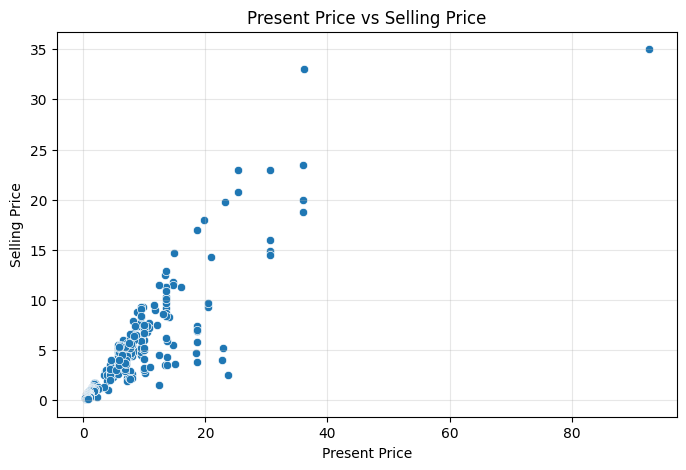

In [14]:
# Present Price vs Selling Price

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Present_Price", y="Selling_Price")
plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")
plt.grid(alpha=0.3)
plt.show()


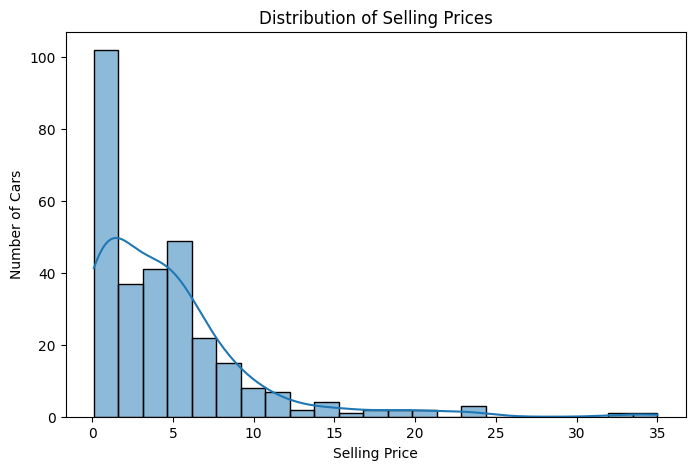

In [15]:
# Selling Price Distribution

plt.figure(figsize=(8, 5))
sns.histplot(df["Selling_Price"], kde=True)
plt.title("Distribution of Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.show()


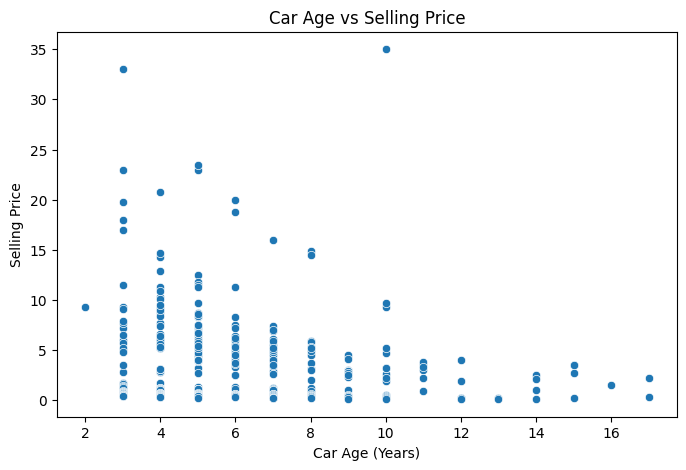

In [16]:
# Car Age Analysis

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Car_Age", y="Selling_Price")
plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price")
plt.show()


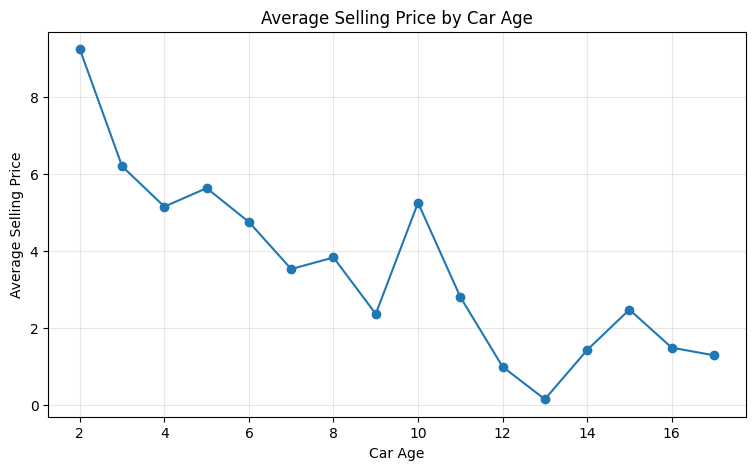

In [17]:
# Average Selling Price by Car Age

age_price = df.groupby("Car_Age")["Selling_Price"].mean().sort_index()

plt.figure(figsize=(9, 5))
plt.plot(age_price.index, age_price.values, marker="o")
plt.title("Average Selling Price by Car Age")
plt.xlabel("Car Age")
plt.ylabel("Average Selling Price")
plt.grid(alpha=0.3)
plt.show()


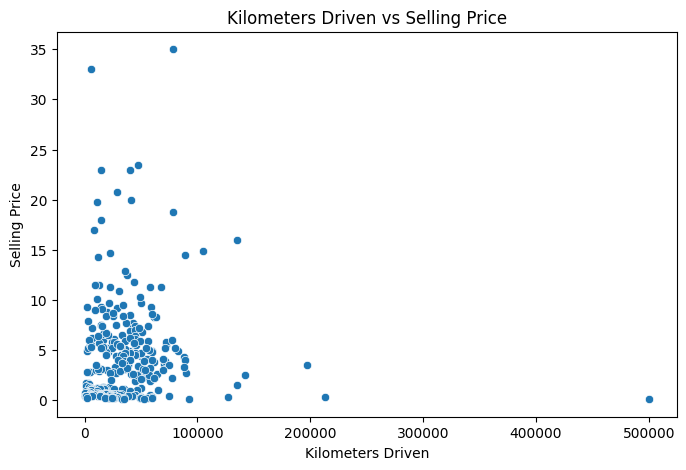

In [18]:
# Kilometers Driven vs Selling Price

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Kms_Driven", y="Selling_Price")
plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.show()


Kms_Category
0–20K       4.072970
20K–50K     4.743182
50K–100K    5.096724
100K+       4.902500
Name: Selling_Price, dtype: float64


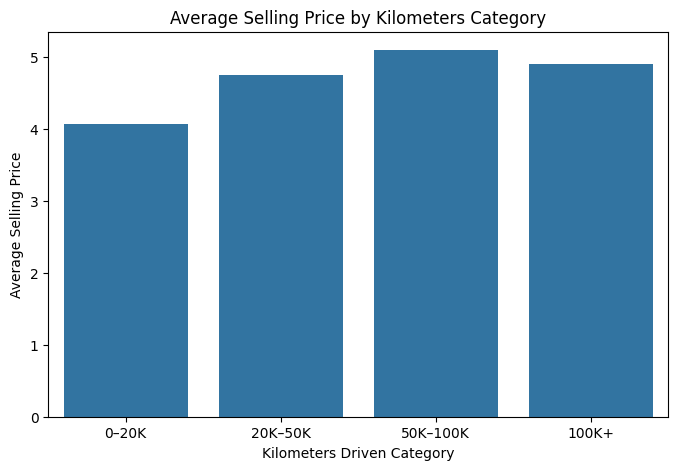

In [19]:
# Average Selling Price by Kilometers Category

kms_price = df.groupby("Kms_Category", observed=False)["Selling_Price"].mean()

print(kms_price)

plt.figure(figsize=(8, 5))
sns.barplot(x=kms_price.index, y=kms_price.values)
plt.title("Average Selling Price by Kilometers Category")
plt.xlabel("Kilometers Driven Category")
plt.ylabel("Average Selling Price")
plt.show()


Fuel_Type
Diesel    10.102759
Petrol     3.264184
CNG        3.100000
Name: Selling_Price, dtype: float64


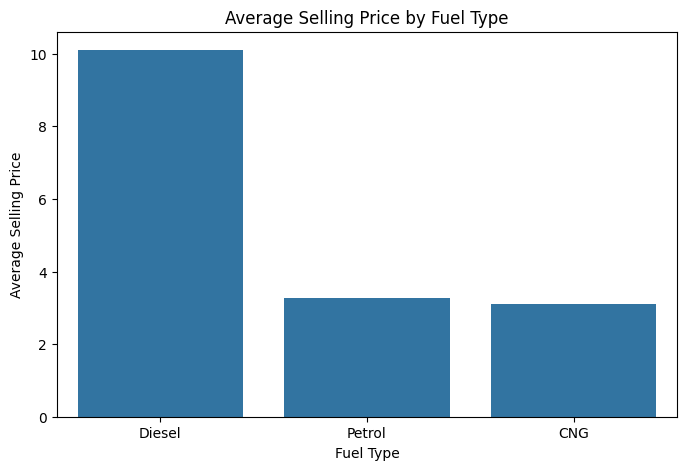

In [20]:
# Fuel Type Analysis

fuel_price = df.groupby("Fuel_Type")["Selling_Price"].mean().sort_values(ascending=False)

print(fuel_price)

plt.figure(figsize=(8, 5))
sns.barplot(x=fuel_price.index, y=fuel_price.values)
plt.title("Average Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Selling Price")
plt.show()


Seller_Type
Dealer        6.632021
Individual    0.870943
Name: Selling_Price, dtype: float64


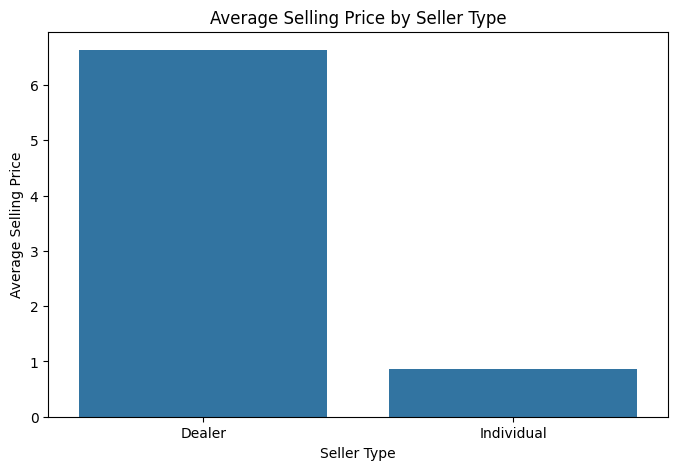

In [21]:
# Seller Type Analysis

seller_price = df.groupby("Seller_Type")["Selling_Price"].mean().sort_values(ascending=False)

print(seller_price)

plt.figure(figsize=(8, 5))
sns.barplot(x=seller_price.index, y=seller_price.values)
plt.title("Average Selling Price by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Average Selling Price")
plt.show()


Transmission
Automatic    9.071795
Manual       3.917308
Name: Selling_Price, dtype: float64


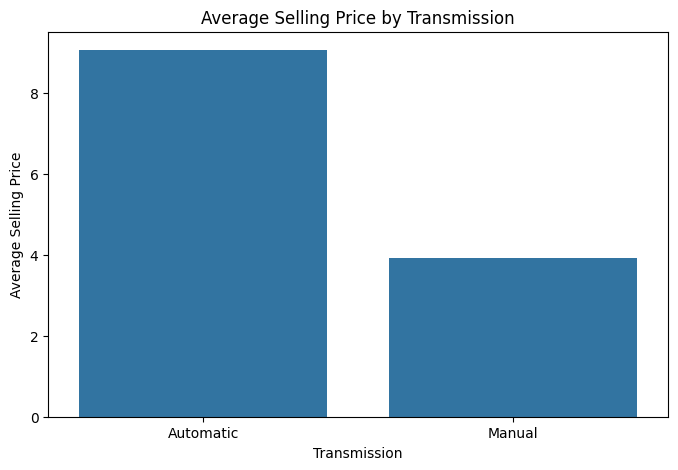

In [22]:
# Transmission Analysis

transmission_price = df.groupby("Transmission")["Selling_Price"].mean().sort_values(ascending=False)

print(transmission_price)

plt.figure(figsize=(8, 5))
sns.barplot(x=transmission_price.index, y=transmission_price.values)
plt.title("Average Selling Price by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Average Selling Price")
plt.show()


Owner_Label
First Owner      4.687847
Fourth+ Owner    2.500000
Second Owner     1.970000
Name: Selling_Price, dtype: float64


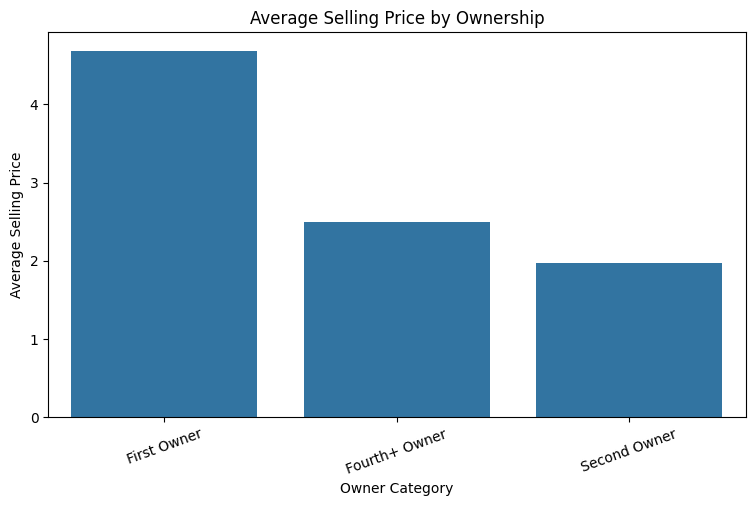

In [23]:
# Ownership Analysis

owner_price = df.groupby("Owner_Label", observed=False)["Selling_Price"].mean()

print(owner_price)

plt.figure(figsize=(9, 5))
sns.barplot(x=owner_price.index, y=owner_price.values)
plt.title("Average Selling Price by Ownership")
plt.xlabel("Owner Category")
plt.ylabel("Average Selling Price")
plt.xticks(rotation=20)
plt.show()


In [24]:
# Top expensive car models with at least 3 listings

model_summary = (
    df.groupby("Car_Name")
    .agg(
        Listings=("Car_Name", "size"),
        Average_Selling_Price=("Selling_Price", "mean")
    )
    .reset_index()
)

model_summary_filtered = model_summary[model_summary["Listings"] >= 3]

top_models = model_summary_filtered.sort_values(
    "Average_Selling_Price", ascending=False
).head(10)

top_models


,Car_Name,Listings,Average_Selling_Price
81,fortuner,10,18.254000
86,innova,9,12.777778
72,creta,3,11.800000
68,ciaz,9,7.472222
69,city,26,7.419231
71,corolla altis,16,7.183125
76,ertiga,5,6.580000
94,verna,14,6.107857
87,jazz,7,5.828571
97,xcent,3,4.966667


In [25]:
# Least expensive models with at least 3 listings

least_expensive = model_summary_filtered.sort_values(
    "Average_Selling_Price", ascending=True
).head(10)

least_expensive


,Car_Name,Listings,Average_Selling_Price
14,Bajaj Pulsar 150,4,0.300000
16,Bajaj Pulsar NS 200,3,0.483333
51,TVS Apache RTR 160,3,0.556667
60,Yamaha FZ S V 2.0,3,0.603333
32,Honda CB Hornet 160R,3,0.716667
6,Bajaj Avenger 220,3,0.790000
46,Royal Enfield Classic 350,7,1.144286
48,Royal Enfield Thunder 350,4,1.162500
49,Royal Enfield Thunder 500,3,1.300000
96,wagon r,4,2.512500


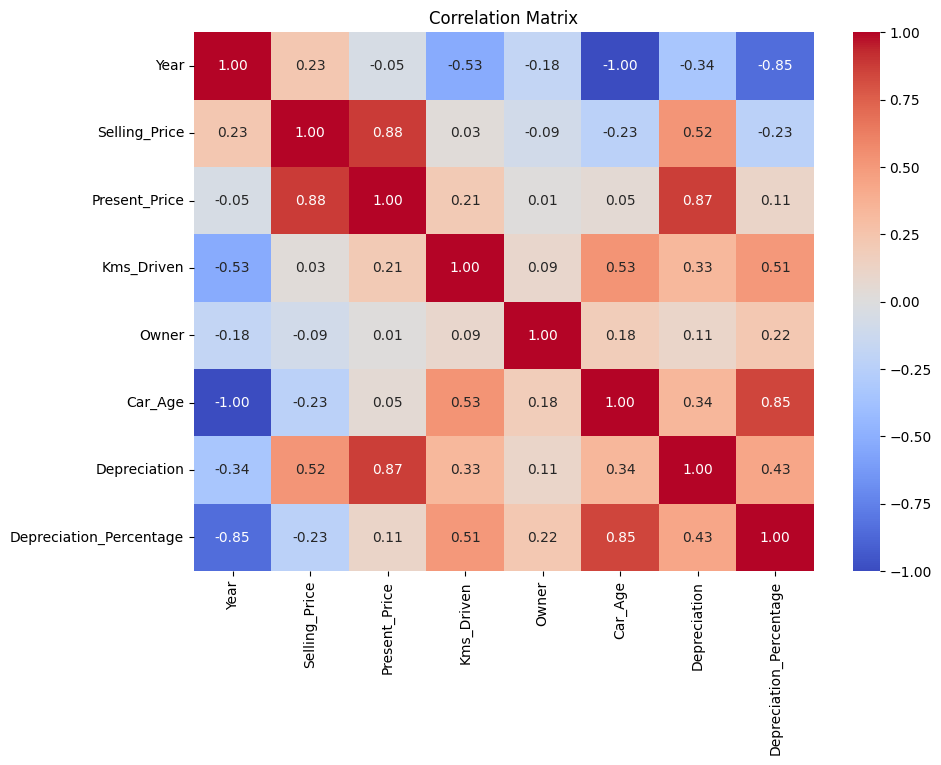

In [26]:
# Correlation Analysis

numeric_columns = [
    "Year",
    "Selling_Price",
    "Present_Price",
    "Kms_Driven",
    "Owner",
    "Car_Age",
    "Depreciation",
    "Depreciation_Percentage"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


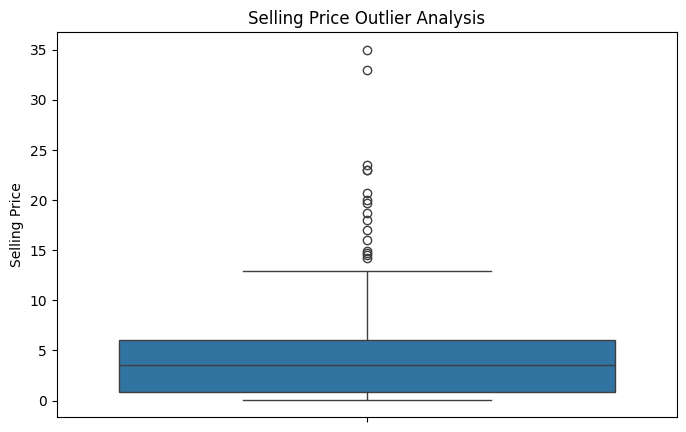

In [27]:
# Outlier Analysis

plt.figure(figsize=(8, 5))
sns.boxplot(y=df["Selling_Price"])
plt.title("Selling Price Outlier Analysis")
plt.ylabel("Selling Price")
plt.show()


# Additional Analysis: Depreciation

Depreciation percentage is analyzed to provide an additional market perspective beyond the core reference workflow.


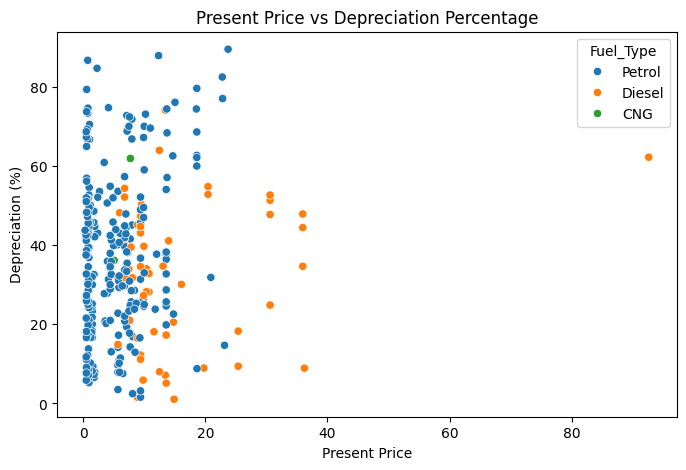

In [28]:
# Present Price vs Depreciation Percentage

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Present_Price",
    y="Depreciation_Percentage",
    hue="Fuel_Type"
)
plt.title("Present Price vs Depreciation Percentage")
plt.xlabel("Present Price")
plt.ylabel("Depreciation (%)")
plt.show()


Average Depreciation Percentage by Fuel Type:
Fuel_Type
CNG       49.017809
Petrol    37.585115
Diesel    32.225727
Name: Depreciation_Percentage, dtype: float64


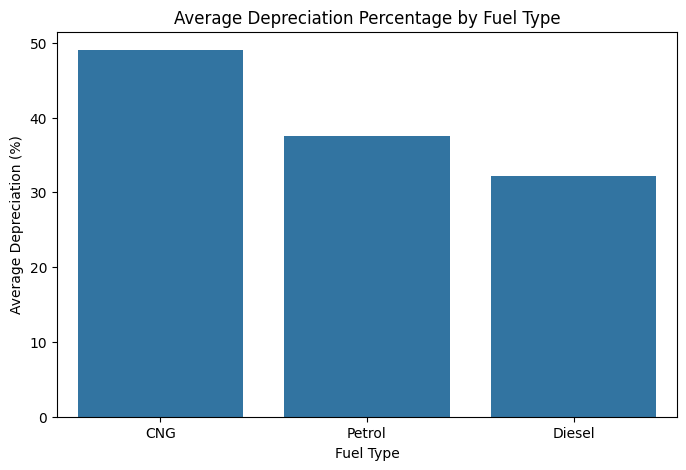

In [29]:
# Average Depreciation Percentage by Fuel Type

fuel_depreciation = (
    df.groupby("Fuel_Type")["Depreciation_Percentage"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Depreciation Percentage by Fuel Type:")
print(fuel_depreciation)

plt.figure(figsize=(8, 5))
sns.barplot(x=fuel_depreciation.index, y=fuel_depreciation.values)
plt.title("Average Depreciation Percentage by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Depreciation (%)")
plt.show()


# Machine Learning — Selling Price Prediction

Two regression models are used to predict the selling price:
- Linear Regression
- Random Forest Regression


In [30]:
# Prepare data for machine learning

features = [
    "Present_Price",
    "Kms_Driven",
    "Car_Age",
    "Fuel_Type",
    "Seller_Type",
    "Transmission",
    "Owner"
]

target = "Selling_Price"

X = df[features].copy()
y = df[target].copy()

X = pd.get_dummies(
    X,
    columns=["Fuel_Type", "Seller_Type", "Transmission"],
    drop_first=True
)

print("Features prepared for machine learning.")
print("Feature shape:", X.shape)


Features prepared for machine learning.
Feature shape: (299, 8)


In [31]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))


Training records: 239
Testing records: 60


In [32]:
# Linear Regression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_lr = linear_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", round(mae_lr, 3))
print("RMSE:", round(rmse_lr, 3))
print("R²  :", round(r2_lr, 3))


Linear Regression Results
-------------------------
MAE : 1.473
RMSE: 2.524
R²  : 0.753


In [33]:
# Random Forest Regression

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE :", round(mae_rf, 3))
print("RMSE:", round(rmse_rf, 3))
print("R²  :", round(r2_rf, 3))


Random Forest Results
---------------------
MAE : 1.445
RMSE: 3.449
R²  : 0.538


In [34]:
# Compare models

model_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R2 Score": [r2_lr, r2_rf]
})

model_results


,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.472892,2.524035,0.752815
1,Random Forest,1.445277,3.448892,0.538481


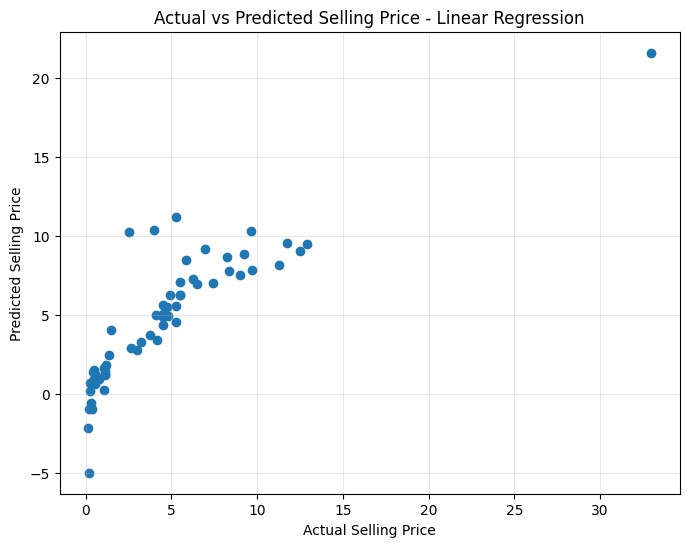

In [35]:
# Actual vs Predicted Selling Price

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price - Linear Regression")
plt.grid(alpha=0.3)
plt.show()


Present_Price             0.905056
Car_Age                   0.071554
Kms_Driven                0.013649
Transmission_Manual       0.005364
Seller_Type_Individual    0.002579
Fuel_Type_Petrol          0.000905
Fuel_Type_Diesel          0.000882
Owner                     0.000010
dtype: float64


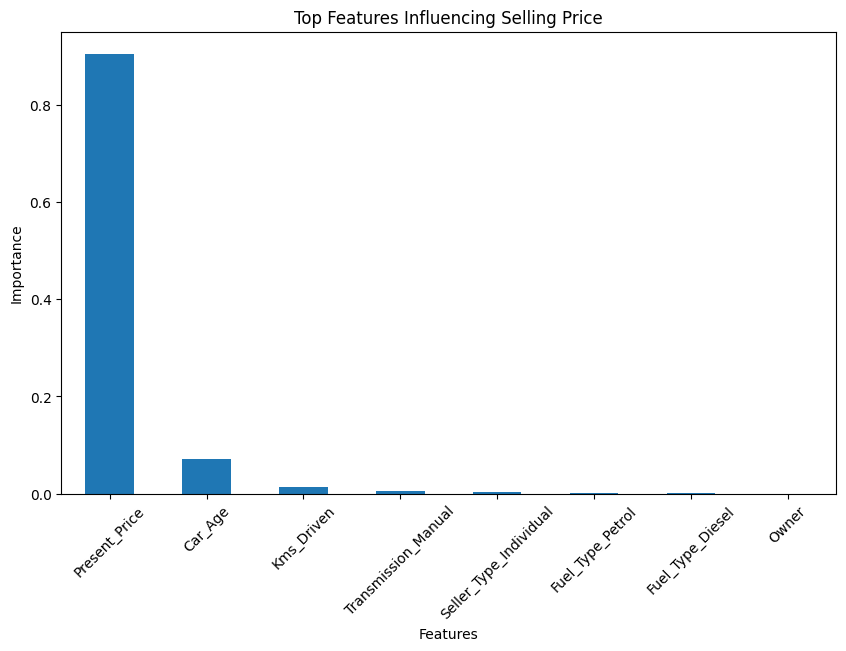

In [36]:
# Feature Importance

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

plt.figure(figsize=(10, 6))
feature_importance.head(10).plot(kind="bar")
plt.title("Top Features Influencing Selling Price")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()


In [37]:
# Automatic Key Findings

print("========== KEY FINDINGS ==========")
print("1. Average selling price:", round(df["Selling_Price"].mean(), 2))
print("2. Average present price:", round(df["Present_Price"].mean(), 2))
print("3. Average car age:", round(df["Car_Age"].mean(), 2), "years")
print("4. Most common fuel type:", df["Fuel_Type"].mode()[0])
print("5. Most common seller type:", df["Seller_Type"].mode()[0])
print("6. Most common transmission:", df["Transmission"].mode()[0])
print("7. Most common owner category:", df["Owner_Label"].mode()[0])
print("8. Highest average-priced model with at least 3 listings:", top_models.iloc[0]["Car_Name"])
print("9. Best R² among tested models:",
      model_results.loc[model_results["R2 Score"].idxmax(), "Model"])


========== KEY FINDINGS ==========
1. Average selling price: 4.59
2. Average present price: 7.54
3. Average car age: 6.38 years
4. Most common fuel type: Petrol
5. Most common seller type: Dealer
6. Most common transmission: Manual
7. Most common owner category: First Owner
8. Highest average-priced model with at least 3 listings: fortuner
9. Best R² among tested models: Linear Regression


# Conclusion

The CarDekho used-car dataset was analyzed to understand the major factors influencing used-car selling prices.

The analysis examined present price, car age, kilometers driven, fuel type, seller type, transmission, and ownership.

Exploratory data analysis was used to identify pricing patterns and depreciation trends. Two machine learning approaches, Linear Regression and Random Forest Regression, were evaluated using MAE, RMSE, and R² metrics.

The project demonstrates how data analysis and machine learning can be used to understand used-car market trends and support better pricing decisions.

### Student Details

**C PUSHPALATHA**  
**AICTE ID:** STU696132c929d891767977673  
**Justice Basheer Ahmed Sayeed College for Women**  
**GitHub:** cpushpalatha9
